# Extended Data Fig. 24 - Optical-to-physical section correspondence mapping

Same-brain validation: WT brains (1 and 9 months; n=1/age) imaged in 3D, then physically sectioned (80 sections: 20 x 2 stains x 2 ages), stained with DAB (NeuN or Iba1) + Hematoxylin, and computationally mapped to the Neuron Atlas. Physical-section nuclei detected with StarDist, classified by DAB intensity.

This notebook contains the parts specific to the optical-to-physical correspondence:
1. Physical-section -> Neuron Atlas registration (ANTs).
2. Cell-point region-ID assignment: 99.6% of physically detected NeuN nuclei assigned to the nearest optical nucleus (within 100 um).
3. NCC of matched vs shifted optical/physical sections.

> The 2D-vs-3D regional density correlation and the <=10% error / regression analyses use the same code as the 2D-sampling family and are shown once in `ED26-28_2D_multisection_sampling_recall.ipynb`. Schematic / representative-image panels are histology images (not code). Figures preserved from the original run; Japanese stripped; verbose logs removed.

## Input files

| File | Content |
|---|---|
| physical section images (DAB NeuN/Iba1 + Hematoxylin) | detection/registration input |
| StarDist nuclei detections + DAB-intensity classification | physical-section cells |
| Neuron Atlas reference + ANTs transforms | registration target |
| optical 3D cell points | nearest-nucleus assignment (99.6%) |

## 1. Physical-section -> Neuron Atlas registration (ANTs)

In [ ]:
#!/usr/bin/env python
# -*- coding:utf-8 -*-
"""
NeuN  -> Atlas    - v18.1 (XY Swap + Hist Swap Test)

-  : NeuN  (CSV)  NeuN->Atlas   ANTs  
        Affine Atlas 
        ANTs 
-  :  fwd.mat + inv.nii.gz  
           whichtoinvert=[True, False]  
-     (v18.1)  
- ants.apply_transforms_to_points   DataFrame   X Y  (v18) 
-   ANTs histogram2d   X, Y   ** **  
- ANTs  [inv_warp, fwd_affine], whichtoinvert=[F, T] (v17 ) 
- Pre/Post ANTs Density Map  
-  :
    - NeuN CSV
    - NeuN->Atlas ANTs  (sXXX_fwd.mat, sXXX_inv.nii.gz)
    - NeuN slice_1.tif ( )
    - NeuN Affine  (sXXX_atlas_affined_template.tif) -  
-  :
    - ANTs  (sXXX_NeuN_points_scaled_pre_ants.tif)
    - ANTs  (sXXX_NeuN_points_mapped_to_affined_atlas_XYSwapInOutTest.tif) <-  
"""

import tifffile
import numpy as np
import os
import glob
from natsort import natsorted
# import h5py
import scipy.io
# import scipy.ndimage
# import skimage.transform
# from scipy.interpolate import interpn
import ants # ANTsPy
from tqdm import tqdm
import pandas as pd
import shutil
import re
import traceback #  
import time #    

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

#
BASE_DATA_PATH = "/data5/Neurology_project_data_archive/mitani/Neurology/2D_slice_data/raw"
#
STARDIST_OUTPUT_BASE = os.path.join(BASE_DATA_PATH, "output_stardist")
#
REGISTRATION_FOLDER_NAME = "folder_registration"
#
OUTPUT_DEBUG_FOLDER = "debug_NeuN_points_pre_post_ants_XYSwapInOut" #   v18.1

#
TARGET_NEUN_SAMPLE = "WT_9m_NeuN_Hippocampus"

#
NEUN_THRESHOLD = 0.3

#
SCALE_FACTOR = 0.02

#
SKIP_IF_EXISTS = 0

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
def find_neun_csv(sample_name, slice_id):
    """  NeuN slice_id   CSV  """
    csv_dir = os.path.join(STARDIST_OUTPUT_BASE, sample_name, "csv_results")
    pattern = f"cell_count_results_{slice_id}_thresh{NEUN_THRESHOLD}.csv"
    csv_path = os.path.join(csv_dir, pattern)
    if os.path.exists(csv_path):
        return csv_path, None
    else:
        #
        fallback_pattern = f"cell_count_results_{slice_id}.csv"
        csv_path_alt = os.path.join(csv_dir, fallback_pattern)
        if os.path.exists(csv_path_alt):
             tqdm.write(f"      ->  : Using fallback CSV pattern for {slice_id}: {fallback_pattern}")
             return csv_path_alt, None
        return None, f"NeuN CSV not found for {slice_id} (tried {pattern} and {fallback_pattern})"


# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
def main_neun_test():
    """NeuN  -> Atlas   """
    print("--- NeuN Point Mapping Test (v18.1 - XY Swap In & Out Test) ---") #  
    print(f"Target NeuN Sample: {TARGET_NEUN_SAMPLE}")
    print(f"SCALE_FACTOR: {SCALE_FACTOR} (applied BEFORE ANTs)")
    print(f"ANTs Transform: Applying Inv Warp THEN Inv Affine using [inv_warp, fwd_affine] with invert=[F, T]")
    print(f"  Testing with swapped X/Y columns passed to ANTs AND swapped back for histogram  ") #  

    sample_path = os.path.join(BASE_DATA_PATH, TARGET_NEUN_SAMPLE)
    if not os.path.isdir(sample_path):
        print(f" : NeuN : {sample_path}"); return

    #
    debug_output_dir = os.path.join(sample_path, OUTPUT_DEBUG_FOLDER)
    os.makedirs(debug_output_dir, exist_ok=True)
    print(f"  Output Debug Folder: {debug_output_dir}")

    #
    neun_reg_base_path = os.path.join(sample_path, REGISTRATION_FOLDER_NAME)
    if not os.path.isdir(neun_reg_base_path):
        print(f"  ->  : NeuN : {neun_reg_base_path} ")
        return
        
    glob_pattern = os.path.join(neun_reg_base_path, 'folder_dst_s*')
    dst_folders = natsorted(glob.glob(glob_pattern))

    if not dst_folders:
        print(f"  ->  : NeuN  'folder_dst_s*'   (Pattern: {glob_pattern})"); return

    print(f"  {len(dst_folders)}   NeuN  ...")
    
    #
    for ap_histology_dir_neun in tqdm(dst_folders, desc=f"Testing NeuN Mapping (XY Swap In/Out)", unit="slice"): #   tqdm  
        
        slice_processing_start_time = time.time()
        
        folder_basename = os.path.basename(ap_histology_dir_neun)
        match = re.search(r'folder_dst_(s\d+)', folder_basename)
        if not match:
            tqdm.write(f"\n  ->  :   slice_id  : {folder_basename} "); continue
        
        slice_id_neun = match.group(1)
        tqdm.write(f"\n--- Processing NeuN Slice: {slice_id_neun} ---")

        #
        #
        csv_path, csv_err = find_neun_csv(TARGET_NEUN_SAMPLE, slice_id_neun)

        #
        neun_to_atlas_ants_output_dir = os.path.join(ap_histology_dir_neun, f"ants_registration_output_SyN_{slice_id_neun}")
        neun_to_atlas_fwd_affine_path = os.path.join(neun_to_atlas_ants_output_dir, f"{slice_id_neun}_fwd.mat")
        neun_to_atlas_inv_warp_path = os.path.join(neun_to_atlas_ants_output_dir, f"{slice_id_neun}_inv.nii.gz") #   INV Warp  

        #
        neun_affined_template_atlas_path = os.path.join(neun_to_atlas_ants_output_dir, f"{slice_id_neun}_atlas_affined_template.tif")

        #
        neun_slice1_path = os.path.join(ap_histology_dir_neun, 'slice_1.tif')
        
        #
        output_density_pre_ants_path = os.path.join(debug_output_dir, f"{slice_id_neun}_NeuN_points_scaled_pre_ants.tif") # ★ Pre-ANTs
        output_density_post_ants_path = os.path.join(debug_output_dir, f"{slice_id_neun}_NeuN_points_mapped_to_affined_atlas_XYSwapInOutTest.tif") #   Post-ANTs,  

        #
        files_ok = True
        tqdm.write("    Checking required files...")
        required_files_list = [
            (csv_path, f"NeuN CSV"),
            (neun_to_atlas_fwd_affine_path, f"NeuN->Atlas Fwd Affine"),
            (neun_to_atlas_inv_warp_path, f"NeuN->Atlas Inv Warp"),
            (neun_affined_template_atlas_path, f"NeuN Affined Template (for shape)"),
            (neun_slice1_path, f"NeuN slice_1.tif (for shape)"),
        ]
        if csv_err:
             tqdm.write(f"      ->  : {csv_err} ")
             files_ok = False

        for file_path, description in required_files_list:
            if file_path and not os.path.exists(file_path):
                 tqdm.write(f"      ->  : {description} ({os.path.basename(file_path)})  ")
                 files_ok = False

        if not files_ok:
            tqdm.write(f"     : {slice_id_neun}")
            continue

        #
        if SKIP_IF_EXISTS and os.path.exists(output_density_pre_ants_path) and os.path.exists(output_density_post_ants_path):
             tqdm.write(f"     : {slice_id_neun}")
             continue

        tqdm.write(f"    All required files found for {slice_id_neun}.")

        #
        try:
            processing_step_start_time = time.time()
            tqdm.write("    (1/5) Reading NeuN CSV...")
            df_coords = pd.read_csv(csv_path)
            df_coords_clean = df_coords.dropna(subset=['centroid_x', 'centroid_y']).copy()
            if df_coords_clean.empty:
                tqdm.write(f"       -> INFO: NeuN CSV  ")
                continue
            tqdm.write(f"      NeuN CSV read ({len(df_coords_clean)} points) ({time.time() - processing_step_start_time:.2f}s)")

            points_2d_highres = df_coords_clean[['centroid_x', 'centroid_y']].values

            #
            processing_step_start_time = time.time()
            tqdm.write("    (2/5) Scaling points...")
            points_2d_lowres = points_2d_highres * SCALE_FACTOR
            #
            points_df_ants_swapped = pd.DataFrame({
                'x': points_2d_lowres[:, 1], # 'x'  Y 
                'y': points_2d_lowres[:, 0]  # 'y'  X 
            }, index=df_coords_clean.index)
            tqdm.write(f"      Scaling done ({time.time() - processing_step_start_time:.2f}s). Passing swapped X/Y to ANTs.")

            #
            try:
                processing_step_start_time = time.time()
                tqdm.write("    (3/5) Generating PRE-ANTs density map (original XY)...")
                
                #
                try:
                    ref_img_slice1 = tifffile.imread(neun_slice1_path)
                    target_H_s1, target_W_s1 = ref_img_slice1.shape[:2]
                except Exception as e_shape_s1:
                     tqdm.write(f"       ->  :   ({os.path.basename(neun_slice1_path)})  : {e_shape_s1} Pre-ANTs ")
                     raise

                #
                points_x_pre = points_2d_lowres[:, 0] #  X
                points_y_pre = points_2d_lowres[:, 1] #  Y
                
                density_map_pre, _, _ = np.histogram2d(
                    points_x_pre, points_y_pre,
                    bins=(target_W_s1, target_H_s1),
                    range=[[0, target_W_s1-1], [0, target_H_s1-1]]
                )
                
                tifffile.imwrite(output_density_pre_ants_path, density_map_pre.T.astype(np.float32))
                tqdm.write(f"      PRE-ANTs density map saved ({time.time() - processing_step_start_time:.2f}s).")

            except Exception as e_hist_pre:
                tqdm.write(f"       ->  : PRE-ANTs  : {e_hist_pre}\n{traceback.format_exc()}")
                #
            #


            #
            #
            transform_list_apply = [
                neun_to_atlas_fwd_affine_path, # T2 ( ) -> inv Affine (whichtoinvert=True)
                neun_to_atlas_inv_warp_path    # T1 ( ) -> inv Warp (whichtoinvert=False)
            ]
            points_on_affined_atlas = None #  
            try:
                processing_step_start_time = time.time()
                tqdm.write(f"    (4/5) Applying ANTs transform (NeuN->Atlas, inv Warp then inv Aff, XY SWAPPED input)...")
                points_on_affined_atlas = ants.apply_transforms_to_points(
                    dim=2, points=points_df_ants_swapped, #   XY  DF  
                    transformlist=transform_list_apply,
                    whichtoinvert=[True, False], #    : Affine=T, Warp=F
                    verbose=True
                )
                tqdm.write(f"      ANTs transform applied ({time.time() - processing_step_start_time:.2f}s).")
                if points_on_affined_atlas is None or not isinstance(points_on_affined_atlas, pd.DataFrame):
                     raise ValueError("apply_transforms_to_points returned invalid result.")
            except Exception as e_ants:
                tqdm.write(f"\n★★★ ANTs Error (apply_transforms_to_points): {e_ants}\n{traceback.format_exc()}")
                continue

            #
            try:
                processing_step_start_time = time.time()
                tqdm.write("    (5/5) Generating POST-ANTs density map (swapping XY back for histogram)...") #    
                
                #
                try:
                    ref_img_affine = tifffile.imread(neun_affined_template_atlas_path)
                    target_H_aff, target_W_aff = ref_img_affine.shape[:2]
                except Exception as e_shape_aff:
                     tqdm.write(f"       ->  :   ({os.path.basename(neun_affined_template_atlas_path)})  : {e_shape_aff} Post-ANTs ")
                     continue

                #
                #
                points_x_post = points_on_affined_atlas['y'].values #   'y'   ( X )   X  
                points_y_post = points_on_affined_atlas['x'].values #   'x'   ( Y )   Y  
                
                density_map_post, _, _ = np.histogram2d(
                    points_x_post, points_y_post,
                    bins=(target_W_aff, target_H_aff),
                    range=[[0, target_W_aff-1], [0, target_H_aff-1]]
                )
                
                tifffile.imwrite(output_density_post_ants_path, density_map_post.T.astype(np.float32))
                tqdm.write(f"      POST-ANTs density map saved ({time.time() - processing_step_start_time:.2f}s).")

            except Exception as e_hist_post:
                tqdm.write(f"       ->  : POST-ANTs  : {e_hist_post}\n{traceback.format_exc()}")
                continue
            #

        except Exception as e:
            #
            tqdm.write(f"\n    (NeuN Slice: {slice_id_neun}  ): {e}\n{traceback.format_exc()}")
            continue #  
            
        tqdm.write(f"--- NeuN Slice: {slice_id_neun} processed in {time.time() - slice_processing_start_time:.2f}s ---")

    print("\n---     NeuN   ---")

if __name__ == '__main__':
    main_neun_test()



## 2. Cell-point region-ID assignment (cKDTree); 99.6% of physical NeuN nuclei matched to optical nuclei

In [ ]:
#!/usr/bin/env python
# -*- coding:utf-8 -*-

import pandas as pd
import numpy as np
import os
import glob
from natsort import natsorted
from scipy.spatial import cKDTree
import tifffile
import gc
from tqdm import tqdm

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

#
BASE_DATA_PATH = "/data5/Neurology_project_data_archive/mitani/Neurology/2D_slice_data/raw"

#
TARGET_SAMPLES = [
    "WT_9m_NeuN_Hippocampus",
    #"WT_1m_NeuN_Hippocampus",
    #"WT_9m_NeuN_Cortex1",
    #"WT_1m_NeuN_Cortex1",
]

#
ANALYSIS_OUTPUT_BASE = "NeuN_stardist_analysis_output"

#
#
PATH_ANNOTATION_VOLUME = '/data4/Neurology_project_data_archive/atlas/annotation_10_LUT_modified_final.tif'


# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

def add_annotation_ids_to_cell_csvs():
    """
    cKDTree  NeuN   CSV  'annotation_id'  
    """
    print("\n---  : cKDTree ID    ---")
    
    #
    try:
        annotation_vol = tifffile.imread(PATH_ANNOTATION_VOLUME)
        print(f"  ->  : {PATH_ANNOTATION_VOLUME} (Shape: {annotation_vol.shape})")
    except FileNotFoundError:
        print(f"   :  : {PATH_ANNOTATION_VOLUME}")
        return
    except Exception as e:
        print(f"   :  : {e}")
        return
        
    coords = np.argwhere(annotation_vol > 0)
    if coords.size == 0:
        print(f"   :   ( > 0 ) ID ")
        return
        
    values = annotation_vol[coords[:, 0], coords[:, 1], coords[:, 2]]
    
    #
    df_non_zero = pd.DataFrame(coords, columns=['AP', 'DV', 'ML'])
    df_non_zero['id'] = values
    
    #
    df_non_zero[['AP', 'DV', 'ML']] = df_non_zero[['AP', 'DV', 'ML']].astype(np.float32) + 0.5
    
    #
    print(f"  -> {len(df_non_zero)} cKDTree ...")
    tree_points = df_non_zero[['AP', 'DV', 'ML']].values
    tree = cKDTree(tree_points)
    print("  -> cKDTree ")
    
    #
    first_sample_printed = False
    
    #
    for sample_name in tqdm(TARGET_SAMPLES, desc=" "):
        
        #
        csv_path = os.path.join(
            BASE_DATA_PATH, sample_name, 
            ANALYSIS_OUTPUT_BASE, # "NeuN_stardist_analysis_output"
            "mapped_to_3d",
            f"ALL_SLICES_{sample_name}_mapped_3d_original_coords.csv" # "ALL_SLICES_..."
        )
        
        #
        output_csv_path = os.path.join(
            BASE_DATA_PATH, sample_name, 
            ANALYSIS_OUTPUT_BASE, 
            "mapped_to_3d",
            f"ALL_SLICES_{sample_name}_mapped_3d_original_coords_annotated.csv" #     "_annotated"  
        )
        
        if not os.path.exists(csv_path):
            tqdm.write(f"  ->  :  CSV  ( ): {csv_path}")
            continue
            
        try:
            df_points = pd.read_csv(csv_path)
        except Exception as e:
            tqdm.write(f"  ->  : CSV  ({sample_name}): {e}")
            continue

        if df_points.empty:
            tqdm.write(f"  -> INFO: CSV  ({sample_name}) ")
            continue
        
        if 'original_AP' not in df_points.columns:
            tqdm.write(f"  ->  : 'original_AP'   ( ): {sample_name}")
            continue

        #
        point_coords = df_points[['original_AP', 'original_DV', 'original_ML']].values.astype(np.float32)
        distances, indexes = tree.query(point_coords, k=1, n_jobs=-1)
        
        #
        df_points['annotation_id'] = df_non_zero.iloc[indexes]['id'].values
        
        #
        if not first_sample_printed:
            tqdm.write(f"\n--- {sample_name}  CSV  ( 5 ) ---")
            #
            tqdm.write(df_points.head(5).to_string())
            tqdm.write("--- ( ) ---\n")
            first_sample_printed = True #  
        
        #
        try:
            #
            df_points.to_csv(output_csv_path, index=False)
            tqdm.write(f"  ->  : {sample_name}  CSV : \n     {output_csv_path}")
        except Exception as e:
            tqdm.write(f"  ->  : CSV  ({sample_name}): {e}")
            
    #
    del tree, tree_points, df_non_zero, annotation_vol, coords, values
    gc.collect()
    print("---  : C ---")


# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

if __name__ == '__main__':
    
    print("=== NeuN  ID  (cKDTree) ===")
    
    if not os.path.exists(PATH_ANNOTATION_VOLUME):
        print(f"   :  ")
        print(f" : {PATH_ANNOTATION_VOLUME}")
        print(" ")
    else:
        try:
            add_annotation_ids_to_cell_csvs()
            print("\n---     ---")
        except Exception as e:
            print(f"\n   :  ")
            import traceback
            traceback.print_exc()

## 3. NCC of matched vs shifted optical/physical sections

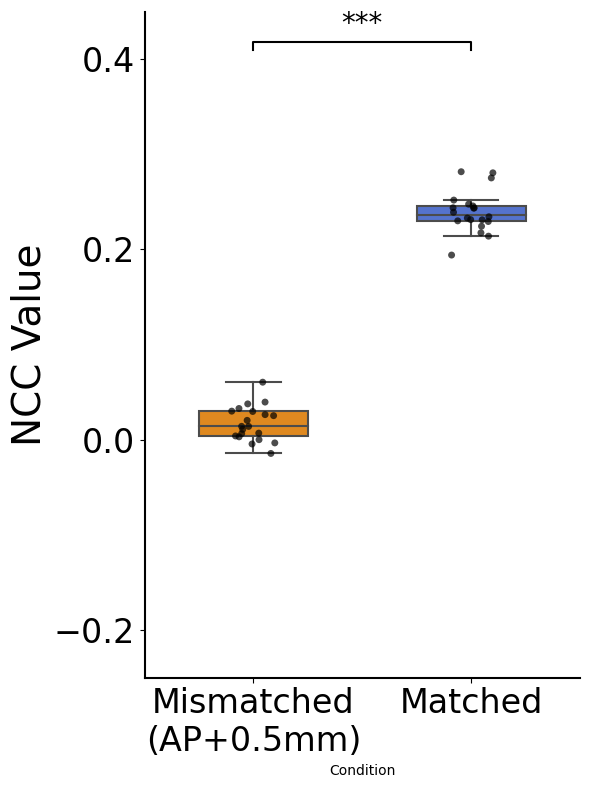

In [1]:
import pandas as pd
import numpy as np
import os
import glob
from natsort import natsorted
import re
import tifffile
from scipy.ndimage import uniform_filter
from tqdm import tqdm
from skimage.transform import rescale
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import wilcoxon #     (Wilcoxon)

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

#
BASE_DATA_PATH = "/data5/Neurology_project_data_archive/mitani/Neurology/2D_slice_data/raw"
STARDIST_OUTPUT_BASE = os.path.join(BASE_DATA_PATH, "output_stardist")
REGISTRATION_FOLDER_NAME = "folder_registration"

#
AP_SHIFT_AMOUNT = 50

#
CSV_DIR = os.path.join(STARDIST_OUTPUT_BASE, "combined_simulation_plots")

#
CSV_PATH_CORRECT = os.path.join(CSV_DIR, "ncc_atlas_vs_debug_density_50um.csv")
COLUMN_NAME_CORRECT = "ncc_mean_50um"
LABEL_CORRECT = "Matched"

#
SHIFT_SUFFIX = f"AP_plus_{AP_SHIFT_AMOUNT}"
CSV_PATH_SHIFTED = os.path.join(CSV_DIR, f"ncc_atlas_vs_debug_density_50um_{SHIFT_SUFFIX}.csv")
COLUMN_NAME_SHIFTED = f"ncc_mean_50um_{SHIFT_SUFFIX}"
LABEL_SHIFTED = f"Mismatched\n(AP+0.5mm)"

#
OUTPUT_PDF_PATH = os.path.join("/data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/2D_Physical_slice_analysis/", f"ncc_comparison_boxplot_{SHIFT_SUFFIX}_mismatch_first.pdf") #    


# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

def main_compare_ncc():
    print("--- NCC   &   (Mismatch ) ---")
    
    try:
        #
        print(f"Loading Correct data: {CSV_PATH_CORRECT}")
        df_correct = pd.read_csv(CSV_PATH_CORRECT)
        
        print(f"Loading Shifted data: {CSV_PATH_SHIFTED}")
        df_shifted = pd.read_csv(CSV_PATH_SHIFTED)

    except FileNotFoundError as e:
        print(f"!!!  :  CSV : {e.filename}")
        return
    except Exception as e:
        print(f"!!!  : CSV : {e}")
        return

    #
    df_correct_slim = df_correct[['slice_id', COLUMN_NAME_CORRECT]].rename(columns={COLUMN_NAME_CORRECT: LABEL_CORRECT})
    df_shifted_slim = df_shifted[['slice_id', COLUMN_NAME_SHIFTED]].rename(columns={COLUMN_NAME_SHIFTED: LABEL_SHIFTED})
    
    df_merged = pd.merge(df_correct_slim, df_shifted_slim, on='slice_id', how='inner')
    
    #
    df_test = df_merged.dropna()
    
    if df_test.empty:
        print("!!!  :  ")
        return
        
    print(f"\n{len(df_test)}  ")

    #
    p_value = np.nan
    try:
        #
        diff = df_test[LABEL_SHIFTED] - df_test[LABEL_CORRECT]
        df_test_wilcoxon = df_test[diff != 0]
        
        if len(df_test_wilcoxon) > 0:
            #
            stat, p_value = wilcoxon(df_test_wilcoxon[LABEL_SHIFTED], df_test_wilcoxon[LABEL_CORRECT])
            print(f"\n--- Wilcoxon Paired Test (N={len(df_test_wilcoxon)}) ---")
            print(f"  Statistic: {stat:.2f}")
            print(f"  P-value: {p_value:.4g}")
        else:
            print("\n--- Wilcoxon Paired Test ---")
            print("   0 ")
            
    except Exception as e:
        print(f"!!!  : {e}")

    #
    df_long = df_test.melt(
        id_vars=['slice_id'], 
        value_vars=[LABEL_SHIFTED, LABEL_CORRECT], #    
        var_name='Condition', 
        value_name='NCC Value' 
    )

    #
    print("\n ...")
    
    plt.style.use('default')
    matplotlib.rcParams['pdf.use14corefonts'] = True
    matplotlib.rcParams['font.family'] = 'Arial'
    matplotlib.rcParams['axes.linewidth'] = 1.5
    plt.rcParams['axes.linewidth'] = 1.5
    
    fig, ax = plt.subplots(figsize=(6, 8)) 

    #
    sns.boxplot(
        data=df_long, 
        x='Condition', 
        y='NCC Value', 
        ax=ax,
        palette=["darkorange", "royalblue"], #    
        width=0.5,
        showfliers=False 
    )
    
    #
    sns.stripplot(
        data=df_long, 
        x='Condition', 
        y='NCC Value', 
        ax=ax,
        color='black',
        alpha=0.7, 
        jitter=0.1
    )

    #
    #ax.set_xlabel('Alignment Condition', fontsize=28)
    ax.set_ylabel('NCC Value', fontsize=28) 
    ax.tick_params(axis='both', which='major', labelsize=24)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    #
    ax.set_ylim(-0.25, 0.45) 
    ax.set_yticks([-0.2, 0.0, 0.2, 0.4])

    #
    if not np.isnan(p_value):
        if p_value < 0.001:
            p_text = "***"
        else:
            p_text = f"p = {p_value:.4g}"
            
        y_pos = 0.41 # Y  (0.45)  
        #
        ax.plot([0, 0, 1, 1], [y_pos, y_pos*1.02, y_pos*1.02, y_pos], lw=1.5, c='black')
        ax.text(0.5, y_pos*1.03, p_text, ha='center', va='bottom', fontsize=20)
        
    plt.tight_layout()

    #
    try:
        plt.savefig(
            OUTPUT_PDF_PATH,
            transparent=True, 
            dpi=300, 
            bbox_inches='tight', 
            pad_inches=0.1
        )
        print(f"\n---     ---")
        print(f"  {OUTPUT_PDF_PATH}  ")
        plt.show()

    except Exception as e:
        print(f"!!!  :  : {e}")


if __name__ == '__main__':
    main_compare_ncc()